<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp?1" width="100px"></a>
</td>
</tr>
</table>

# Chapter 8: Distilling Reasoning Models for Efficient Reasoning

Packages that are being used in this notebook:

In [1]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.17
torch version: 2.10.0
tokenizers version: 0.21.4


<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F01_raschka.webp" width=600>

&nbsp;
## 8.1 Introduction to model distillation for reasoning tasks

- Distillation means training a smaller LLM (the "student") on the outputs of a larger LLM (the "teacher")
- Distillation can be more effective than training with RLVR from scratch
  - For example, the [DeepSeek-R1 paper](https://arxiv.org/abs/2501.12948) reported that for the smaller DeepSeek-R1 model variants, they were able to achieve a better performance through distillation than RLVR
  - In particular, they trained the largest DeepSeek R1 model (671B parameters), and then they used it to train smaller models via distillation

- There are two main types of distillation: hard distillation and soft distillation
  1. Hard distillation: The student is trained on text generated by the teacher (the teacher's outputs are treated as ground-truth targets)
  2. Soft distillation: The student is trained to match the teacher's probability distribution over the vocabulary (typically by minimizing KL divergence between the teacher and student distributions derived from their logits)

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F02_raschka.webp" width=600>

- 1. Pure hard distillation:
  - We only use teacher-generated text as targets (here, the teacher outputs are considered the ground truth targets)
  - Loss: `L = CrossEntropy(y_teacher_tokens, y_student)`
  - Technically, this is standard supervised fine-tuning on synthetic data
  - We don't require access to teacher logits
  - This is what the smaller models in DeepSeek-R1 distillation do: generate reasoning traces via the large 671B DeepSeek-R1 (teacher) and fine-tune smaller LLMs (students) on them

- 2. Pure soft distillation
  - We match the teacher's output probability distribution directly
  - Loss: `L = KL(p_teacher || p_student)`
  - This requires teacher logits (or log-probabilities) at training time

- 3. Combined hard and soft distillation
  - This is classic knowledge distillation (originated in computer vision) described in [Distilling the Knowledge in a Neural Network](https://arxiv.org/abs/1503.02531)
  - We train on the teacher's actual output tokens, but we also force the student to match the teacher's full probability distribution
  - Loss: `L = CE(y_teacher_tokens, y_student) + lambda * KL(p_teacher || p_student)`, where `lambda` is a hyperparameter to tune the individual contribution of the KL term

- Hard distillation is more common in practice
  - Logits are usually inaccessible; i.e., proprietary systems such as OpenAI ChatGPT or Anthropic Claude do not expose full vocabulary logits, which makes classical soft distillation impossible
  - Even if logits are accessible, soft-distillation requires that student and teacher LLMs use the same tokenization; otherwise, the vocabularies won't match (hence, soft-distillation is more useful when staying within this same model family)
  - Note that even generating and reusing the text outputs for distillation may violate certain providers' policies
  - Even when logits are available, storing full vocabulary distributions for long sequences is expensive in terms of bandwidth and disk space; generating and storing plain text outputs is significantly cheaper

- If both soft and hard distillation are feasible, which one performs better?
  - Appropriately designed objectives for soft distillation can outperform hard distillation (https://arxiv.org/abs/2306.08543)
  - But there is no recent large-scale head-to-head comparison on modern LLM benchmarks where soft vs hard is the only varying factor for a fair comparison
  - Data generation strategy can matter more than whether supervision is soft or hard (https://arxiv.org/abs/2306.13649)

- In this chapter, we implement hard distillation similar to DeepSeek-R1, which is the more common and practical approach

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F03_raschka.webp" width=600>

&nbsp;
## 8.2 Generating a dataset for reasoning distillation

- The first step in distillation is to create the dataset for training the student model (here, the Qwen3 0.6B base model we worked with throughout this book)
- We will use the 12,000 math problems from the MATH dataset that are non-overlapping with the MATH-500 test set (https://github.com/rasbt/math_full_minus_math500)
- These are the same 12,000 math problems we used in chapters 6 and 7 for RLVR
- We feed these 12,000 math problems to an existing reasoning model (here, DeepSeek-R1) and collect the responses for training

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F04_raschka.webp" width=500>

- In chapters 6 and 7, we trained the Qwen3 base model with RLVR to generate the correct solution
- The correct solution, using a verifier, was then compared to the reference solution to compute the training signal
- In distillation, we compare the teacher's solution to the student's solution to compute the training signal

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F05_raschka.webp" width=600>

- For our distillation approach, we can use the teacher model to generate the distillation dataset ahead of time, before we start training the student model
- Since generating the teacher answers for all 12,000 math problems can be time- and resource-intensive, I generated the dataset ahead of time using a 671-billion-parameter DeepSeek-R1 model hosted in the cloud via OpenRouter (the dataset cost approximately $50 in API costs to generate)
- In the next section, we will load this pre-generated dataset, so it's not necessary for you to generate this dataset yourself
- However, if you are curious, you can find the code I used, alongside the usage instructions, in the supplementary materials at [https://github.com/rasbt/reasoning-from-scratch/tree/main/ch08/02_generate_distillation_data](https://github.com/rasbt/reasoning-from-scratch/tree/main/ch08/02_generate_distillation_data) 

&nbsp;
## 8.3 Loading the MATH training dataset for distillation

- In this section, we load a dataset of math problems and answers generated by DeepSeek-R1 as described in the previous section

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F06_raschka.webp" width=600>

- The dataset is available from the Hugging Face model hub at https://huggingface.co/datasets/rasbt/math_distill
- The following code loads it into our Python session:

In [2]:
import json
import requests
from pathlib import Path


def load_distill_data(
    local_path=None,
    partition="deepseek-r1-math-train",
    save_copy=True,
):

    if local_path is None:
        local_path = f"{partition}.json"
    local_path = Path(local_path)

    url = (
        "https://huggingface.co/datasets/rasbt/math_distill"
        "/resolve/main/data/"
        f"{partition}.json"
    )
    backup_url = (
        "https://f001.backblazeb2.com/file/reasoning-from-scratch/"
        f"MATH/{partition}.json"
    )

    if local_path.exists():
        with local_path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB (cached)")
        return data

    assert partition in (
        "deepseek-r1-math-train",
        "deepseek-r1-math500",
        "qwen3-235b-a22b-math-train",
        "qwen3-235b-a22b-math500",
    )

    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
    except requests.RequestException:
        print("Using backup URL.")
        r = requests.get(backup_url, timeout=30)
        r.raise_for_status()

    data = r.json()

    if save_copy:
        with local_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)

        size_kb = local_path.stat().st_size / 1e3
        print(f"{local_path}: {size_kb:.1f} KB")

    return data

In [3]:
math_train = load_distill_data(partition="deepseek-r1-math-train")

print("Dataset size:", len(math_train))

deepseek-r1-math-train.json: 107538.0 KB (cached)
Dataset size: 12000


- Let's look at one of the training examples to check the structure:

In [4]:
from pprint import pprint

pprint(math_train[4])

{'gtruth_answer': '6',
 'message_content': 'Sam worked \\( x \\) days and did not work \\( y \\) '
                    'days. We know:\n'
                    '\\[\n'
                    'x + y = 20\n'
                    '\\]\n'
                    'His total earnings are calculated as:\n'
                    '\\[\n'
                    '60x - 30y = 660\n'
                    '\\]\n'
                    'Substituting \\( x = 20 - y \\) into the earnings '
                    'equation:\n'
                    '\\[\n'
                    '60(20 - y) - 30y = 660\n'
                    '\\]\n'
                    'Simplifying:\n'
                    '\\[\n'
                    '1200 - 60y - 30y = 660 \\\\\n'
                    '1200 - 90y = 660 \\\\\n'
                    '-90y = 660 - 1200 \\\\\n'
                    '-90y = -540 \\\\\n'
                    'y = \\frac{-540}{-90} = 6\n'
                    '\\]\n'
                    'Sam did not work \\(\\boxed{6}\\) days.',
 'message_t

In [5]:
math_train[4].keys()

dict_keys(['problem', 'gtruth_answer', 'message_thinking', 'message_content'])

- The dataset contains four fields:
  - `gtruth_answer`: The correct reference answer (ground truth answer)
  - `message_thinking`: The reasoning trace written by the model
  - `message_content`: The final answer, following the reasoning trace
- We can use the following code to format the answer:

In [6]:
def format_distilled_answer(entry):
    content = str(entry["message_content"]).strip()
    if not content:
        raise ValueError("Missing non-empty 'message_content' field.")

    thinking = str(entry["message_thinking"]).strip()
    return f"<think>{thinking}</think>\n\n{content}"

In [7]:
print(format_distilled_answer(math_train[4]))

<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? Is it that he loses $30 per day not worked from his total earnings?

Wait, maybe. So if he didn't work y days, then he loses 30*y dollars. But wait, does he get a base salary and then deductions? Or is his total earnings 60x minus 30y?

The problem says, "On days that he works, he earns $60. For each day that he does not work, $30 is subtracted from his earnings." So probably, his total earnings are calculated by 60

- As discussed in the previous chapter, `<think></think>` tokens are not necessary
- They can be useful to separate the reasoning trace from the final answer
- Some providers and interfaces, like OpenAI's ChatGPT, hide the reasoning trace from the user, and using and teaching the model to use `<think></think>` tokens can make it easier to parse out and hide these thinking traces

- In case you are curious about what accuracy the DeepSeek-R1 model achieved on this dataset, since the dataset contains ground truth labels, we can compute accuracy with the verifier from chapter 3
- For convenience, we can use the [evaluate_json.py](https://github.com/rasbt/reasoning-from-scratch/blob/main/ch03/02_math500-verifier-scripts/evaluate_json.py) script from the supplementary materials (chapter 3) to calculate the accuracy directly from the JSON file

In [8]:
from reasoning_from_scratch.ch07 import download_from_github

_ = download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_json.py"
)

evaluate_json.py: 3.3 KB (cached)


In [9]:
!uv run evaluate_json.py \
--json_path "deepseek-r1-math-train.json" \
--gtruth_answer gtruth_answer \
--generated_text message_content

Accuracy: 90.6% (10871/12000)


&nbsp;
## 8.4 Building training examples

- In this section, we prepare the dataset examples for training

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F07_raschka.webp" width=600>

- This preparation is mainly about formatting and tokenizing the examples
- In RLVR, we did this on the fly since we only used each training example ones
- Distillation, which is a form of supervised fine-tuning, benefits from seeing the same examples multiple times
- So, to avoid duplication efforts, we format and tokenize the samples once and store them for reuse

&nbsp;
### 8.4.1 Loading and understanding the tokenizer

- We start with the tokenizer
- We use the "reasoning" variant as it supports `<think>...</think>` tokens, as discussed in chapter 7

In [10]:
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small,
    Qwen3Tokenizer
)

def load_reasoning_tokenizer(local_dir="qwen3"):
    download_qwen3_small(
        kind="reasoning", tokenizer_only=True, out_dir=local_dir
    )

    tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
    tokenizer = Qwen3Tokenizer(
        tokenizer_file_path=tokenizer_path,
        apply_chat_template=True,
        add_generation_prompt=True,
        add_thinking=True,
    )
    
    return tokenizer


tokenizer = load_reasoning_tokenizer()

✓ qwen3/tokenizer-reasoning.json already up-to-date


- Note that we set `apply_chat_template=True` and `add_generation_prompt=True`, which will apply additional formatting to the prompt, as we can demonstrate as follows:

In [11]:
prompt = "Sam is hired for a 20-day period..."

prompt_ids = tokenizer.encode(prompt)
decoded_prompt = tokenizer.decode(prompt_ids)
print(decoded_prompt)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant



- Here, `<|im_start|>user` act as start tokens for the user provided prompts
- `<|im_end|>` is the stop token for the user-provided prompt
- `<|im_start|>assistant` are the start tokens for the LLM answer
- This formatting is optional, but it is a common and useful convention for instruction/chat fine-tuning
- Also, for the answer, we need to disable this wrapping via `chat_wrapped=False`, otherwise will have too many start tokens since the prompt and answer tokens are meant to be combined for training:

In [12]:
answer = (
    "<think>Okay, let me try to solve "
    "this problem...</think> \\boxed{4}"
)
answer_ids = tokenizer.encode(answer, chat_wrapped=False)
decoded_answer = tokenizer.decode(answer_ids)
print(decoded_answer)

<think>Okay, let me try to solve this problem...</think> \boxed{4}


- For training, we need the combined token IDs including an `<|im_end|>` end-of-sequence token at the end of the answer:

In [13]:
token_ids = prompt_ids + answer_ids + [tokenizer.eos_token_id]
decoded_token_ids = tokenizer.decode(token_ids)
print(decoded_token_ids)

<|im_start|>user
Sam is hired for a 20-day period...<|im_end|>
<|im_start|>assistant
<think>Okay, let me try to solve this problem...</think> \boxed{4}<|im_end|>


- Again, it's worth highlighting that we use the reasoning tokenizer for the <think></think> tokens, but it does not really matter; we could also use the base tokenizer
- The chat template is also optional; we just keep it because that's what Qwen3's own reasoning models use (only matters when working with agents or multi-prompt)
- We need to remember to use `--which_model "reasoning"` in the evaluation script for consistency

&nbsp;
### 8.4.2 Formatting and tokenizing the dataset

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F08_raschka.webp" width=400>

- Below, we develop a `build_examples` function that applies the required formatting to the whole dataset

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F09_raschka.webp" width=600>

In [14]:
from reasoning_from_scratch.ch03 import render_prompt

def build_examples(data, tokenizer):
    examples = []
    skipped = 0

    for entry in data:
        try:
            # Step 1: encode prompt
            prompt = render_prompt(entry["problem"])
            prompt_ids = tokenizer.encode(prompt)

            # Step 2: encode answer
            target_answer = format_distilled_answer(entry)
            answer_ids = tokenizer.encode(
                target_answer, chat_wrapped=False
            )

            # Step 3: Combine prompt and answer
            token_ids = (
                prompt_ids + answer_ids + [tokenizer.eos_token_id]
            )

            if len(token_ids) < 2:
                skipped += 1
                continue

            examples.append({
                "token_ids": token_ids,
                "prompt_len": len(prompt_ids),
            })
        except (KeyError, TypeError, ValueError):
            skipped += 1

    return examples, skipped

In [15]:
examples, skipped = build_examples(math_train, tokenizer)

print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

Number of examples: 12000
Number of skipped examples: 0


In [16]:
print(tokenizer.decode(examples[4]["token_ids"]))

<|im_start|>user
You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Sam is hired for a 20-day period. On days that he works, he earns $\$$60. For each day that he does not work, $\$$30 is subtracted from his earnings. At the end of the 20-day period, he received $\$$660. How many days did he not work?

Answer:<|im_end|>
<|im_start|>assistant
<think>Okay, let's see. Sam was hired for 20 days. Each day he works, he earns $60, but if he doesn't work a day, they deduct $30 from his earnings. At the end of the 20 days, he got $660. I need to find out how many days he didn't work.

Hmm, so let me think. Let's break this down. Let's say he worked x days and didn't work y days. So total days x + y = 20. That's straightforward. Now, his earnings. For each day worked, he gets $60, so total earnings from working would be 60x. But for each day he didn't work, they subtract $30. Wait, how exactly does that subtraction work? I

&nbsp;
### 8.4.3 Filtering and splitting the dataset

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F10_raschka.webp" width=400>

In [17]:
def compute_length(examples, answer_only=False):
    lengths = []
    for ex in examples:
        total = len(ex["token_ids"])
        length = total - ex["prompt_len"] if answer_only else total
        lengths.append(length)

    avg_len = round(sum(lengths) / len(lengths))

    shortest_len = min(lengths)
    longest_len = max(lengths)
    shortest_idx = lengths.index(shortest_len)
    longest_idx = lengths.index(longest_len)

    print(f"Average: {avg_len} tokens")
    print(f"Shortest: {shortest_len} tokens (index {shortest_idx})")
    print(f"Longest: {longest_len} tokens (index {longest_idx})")

compute_length(examples)

Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)


In [18]:
def filter_examples_by_max_len(examples, max_len=2048):
    filtered_examples = [
        s for s in examples
        if len(s["token_ids"]) <= max_len
    ]

    print("Original:", len(examples))
    print("Filtered:", len(filtered_examples))
    print("Removed:", len(examples) - len(filtered_examples))

    return filtered_examples

filtered_examples = filter_examples_by_max_len(examples, max_len=2048)

Original: 12000
Filtered: 6695
Removed: 5305


In [19]:
compute_length(filtered_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


In [20]:
import random

rng = random.Random(123)
rng.shuffle(filtered_examples)

train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]

In [21]:
print("Number of train examples:", len(train_examples))
print("Number of validation examples:", len(val_examples))

Number of train examples: 6670
Number of validation examples: 25


- Exercise: inspect the training and validation set length to ensure they are balanced

In [22]:
compute_length(train_examples)

Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [23]:
compute_length(val_examples)

Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


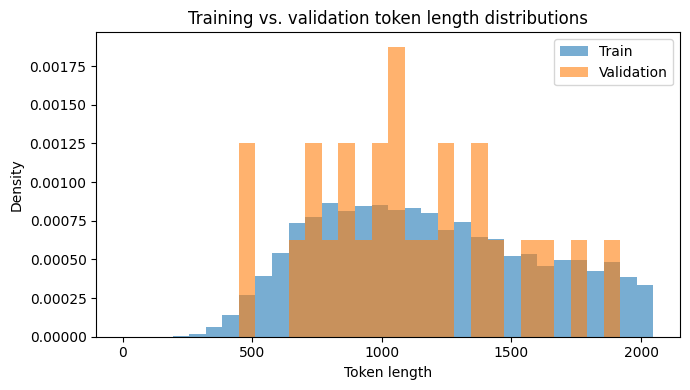

In [24]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()


&nbsp;
## 8.5 Loading a pre-trained model

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F11_raschka.webp" width=600>

In [22]:
import torch

from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()

model, _ = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


&nbsp;
## 8.6 Computing the training and validation losses

- In this section, we implement code to compute the so-called cross-entropy loss, which we will use as a training signal during distillation
- We will also apply it to the validation set for evaluation purposes during training
- Readers with a background in deep learning may already be familiar with cross-entropy in the context of classification problems; this here is the same cross-entropy function, where the prediction target is the next token in the sequence
- We can derive the cross-entropy loss from the logprob computation we calculated in chapters 5 and 6

- As explained in chapter 5, where the logprob computation was first introduced, the logprob calculates a score for the next-generated token
- Higher logprob means the model assigned a higher probability to the correct token (better prediction); lower logprob means a lower probability (worse prediction)
- The figure below reuses the example from chapter 5

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F12_raschka.webp" width=600>

- Similar to what's shown in the figure above, the `sequence_logprob` function from chapter 6 computes the log-probabilities (logprobs) for each token that are then returned as a sum (i.e., the joint log-probability)

- Let's look into this using an example from the training set; (we choose the shortest one to reduce the computation time):

In [23]:
# 5730 is the shortest example in train_examples
token_ids = train_examples[5730]["token_ids"]
prompt_len = train_examples[5730]["prompt_len"]

- Note that instead of reporting the summed logprobs `sequence_logprob` returns, we average the logprobs over the number of answer tokens, which we can compute by subtracting the `prompt_len` from the total number of tokens, which includes prompt and answer tokens:

In [24]:
from reasoning_from_scratch.ch06 import sequence_logprob

tok = torch.tensor(token_ids, dtype=torch.long, device=device)

with torch.no_grad():
    seq_logprob = sequence_logprob(model, tok, prompt_len)
    num_answer_tokens = tok.numel() - prompt_len
    avg_logprob = -seq_logprob / num_answer_tokens
print(f"Average logprob: {avg_logprob:.2f}")

Average logprob: 1.68


- We can compute the same using the `cross_entropy` function
- Note that the function is developed for classification, and next to the model's logits, it expects the class labels as an argument; the class labels here are the "correct" tokens
- Specifically, we compute the cross-entropy over the answer tokens only (ignoring the prompt tokens)

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F13_raschka.webp" width=600>

In [25]:
input_ids = tok[:-1].unsqueeze(0)
target_ids = tok[1:]  # Targets are inputs shifted by one position
logits = model(input_ids).squeeze(0)

# Remove prompt tokens
first_answer_logit_idx = max(prompt_len - 1, 0)
answer_logits = logits[first_answer_logit_idx:]
answer_targets = target_ids[first_answer_logit_idx:]

with torch.no_grad():
    ce_mean_direct = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
print(f"Cross-entropy: {ce_mean_direct:.2f}")

Cross-entropy: 1.68


- As we can see, the result is the same as before when we computed the average logprobs over the answer tokens
- In other words, the `cross_entropy` function implements the average logprob computation internally
- We use the `cross_entropy` function instead of our own `sequence_logprob` function, as it is better optimized for faster training
- Let's put it into a convenient function we can call:

In [26]:
def compute_example_loss(model, example, device):
    token_ids = example["token_ids"]
    prompt_len = example["prompt_len"]

    input_ids = torch.tensor(
        token_ids[:-1], dtype=torch.long, device=device
    ).unsqueeze(0)
    target_ids = torch.tensor(
        token_ids[1:], dtype=torch.long, device=device
    )

    logits = model(input_ids).squeeze(0)

    answer_start = max(prompt_len - 1, 0)
    answer_logits = logits[answer_start:]
    answer_targets = target_ids[answer_start:]

    loss = torch.nn.functional.cross_entropy(
        answer_logits, answer_targets
    )
    return loss

In [27]:
with torch.no_grad():
    loss = compute_example_loss(
        model, train_examples[5730], device
    )

print(f"Loss: {loss:.2f}")

Loss: 1.68


- Note that it is also possible to compute multiple samples in parallel, called batching, but we omit that to keep the resource requirements lower
- Appendix E discusses batching

- We can also define a wrapper function that computes the loss over multiple examples:

In [28]:
@torch.no_grad()
def evaluate_examples(model, examples, device):
    was_training = model.training
    model.eval()
    total_loss = 0.0
    num_examples = 0

    for example in examples:
        loss = compute_example_loss(model, example, device)
        total_loss += loss.item()
        num_examples += 1

    if was_training:
        model.train()

    return total_loss / num_examples

In [29]:
train_loss = evaluate_examples(model, train_examples[:3], device)
print(f"Train loss (3 examples): {train_loss:.2f}")

Train loss (3 examples): 0.98


In [30]:
val_loss = evaluate_examples(model, val_examples[:3], device)
print(f"Validation loss (3 examples): {val_loss:.2f}")

Validation loss (3 examples): 1.02


- We will reuse this function to track the progress during training, where we want to see that the loss decreases

&nbsp;
## 8.7 Implementing the training loop for distillation

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F14_raschka.webp" width=600>

- The training loop is almost identical to chapter 6, except that we now loop over the training set multiple times (epochs) and calculate the cross-entropy loss instead of GRPO loss

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F15_raschka.webp" width=500>

In [31]:
import time


def train_distillation(
    model,
    train_examples,
    val_examples,
    device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=None,
    seed=123,
    log_every=50,
    checkpoint_dir="checkpoints",
    csv_log_path=None,
):
    # Step 1: initialize optimizer (model is already loaded)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()

    total_steps = epochs * len(train_examples)
    global_step = 0
    rng = random.Random(seed)

    if csv_log_path is None:
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        csv_log_path = f"train_distill_metrics_{timestamp}.csv"
    csv_log_path = Path(csv_log_path)

    # Step 2: iterate over training epochs
    for epoch in range(1, epochs + 1):
        # Step 3: shuffle the training examples at the start of the epoch
        epoch_examples = list(train_examples)
        rng.shuffle(epoch_examples)

        # Step 4: iterate over training examples in epoch
        for example in epoch_examples:
            global_step += 1

            # Stage 5: reset loss gradient
            # (it's best practice to do this at the beginning of each step)
            optimizer.zero_grad()

            # Step 6: compute the cross-entropy loss for the current example
            loss = compute_example_loss(model, example, device)

            # Step 7: backpropagate gradients
            loss.backward()

            # Optionally clip large gradients to improve training stability
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), grad_clip_norm
                )

            # Step 8: update the model weights
            optimizer.step()

            # Step 9: periodically evaluate the current model on the validation set
            if log_every and global_step % log_every == 0:
                val_loss = evaluate_examples(
                    model=model,
                    examples=val_examples,
                    device=device,
                )
                model.train()
                print(
                    f"[Epoch {epoch}/{epochs} "
                    f"Step {global_step}/{total_steps}] "
                    f"train_loss={loss.item():.4f} "
                    f"val_loss={val_loss:.4f}"
                )
                append_csv_metrics(
                    csv_log_path=csv_log_path,
                    epoch_idx=epoch,
                    total_steps=global_step,
                    train_loss=loss.item(),
                    val_loss=val_loss,
                )

        # Step 10: save a checkpoint for this epoch
        ckpt_path = save_checkpoint(
            model=model,
            checkpoint_dir=checkpoint_dir,
            step=global_step,
            suffix=f"epoch{epoch}",
        )
        print(f"Saved checkpoint to {ckpt_path}")
    return model


def save_checkpoint(model, checkpoint_dir, step, suffix=""):
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"-{suffix}" if suffix else ""
    ckpt_path = (
        checkpoint_dir /
        f"qwen3-0.6B-distill-step{step:05d}{suffix}.pth"
    )
    torch.save(model.state_dict(), ckpt_path)
    return ckpt_path


def append_csv_metrics(
    csv_log_path,
    epoch_idx,
    total_steps,
    train_loss,
    val_loss,
):
    if not csv_log_path.exists():
        csv_log_path.write_text(
            "epoch,total_steps,train_loss,val_loss\n",
            encoding="utf-8",
        )
    with csv_log_path.open("a", encoding="utf-8") as f:
        f.write(
            f"{epoch_idx},{total_steps},{train_loss:.6f},"
            f"{val_loss:.6f}\n"
        )

- With the sequence length of 2048, the training run requires about 15 GB of RAM
- To lower the resource requirements, you can filter out longer sequences, for example, in the `previous filtered_examples = filter_examples_by_max_len(examples, max_len=2048)` step, changing `max_len` from `2048` to `1024` or `512`

In [32]:
torch.manual_seed(0)

train_distillation(
    model,
    train_examples=train_examples[:10],
    val_examples=val_examples[:10],
    device=device,
    epochs=2,
    lr=5e-6,
    grad_clip_norm=1.0,  # Same as in chapter 6
    seed=123,
    log_every=5,
    csv_log_path="train_distill_metrics.csv"
)

[Epoch 1/2 Step 5/20] train_loss=0.9648 val_loss=0.9082
[Epoch 1/2 Step 10/20] train_loss=0.9844 val_loss=0.8871
Saved checkpoint to checkpoints/qwen3-0.6B-distill-step00010-epoch1.pth
[Epoch 2/2 Step 15/20] train_loss=0.8008 val_loss=0.8707
[Epoch 2/2 Step 20/20] train_loss=0.7148 val_loss=0.8586
Saved checkpoint to checkpoints/qwen3-0.6B-distill-step00020-epoch2.pth


Qwen3Model(
  (tok_emb): Embedding(151936, 1024)
  (trf_blocks): ModuleList(
    (0-27): 28 x TransformerBlock(
      (att): GroupedQueryAttention(
        (W_query): Linear(in_features=1024, out_features=2048, bias=False)
        (W_key): Linear(in_features=1024, out_features=1024, bias=False)
        (W_value): Linear(in_features=1024, out_features=1024, bias=False)
        (out_proj): Linear(in_features=2048, out_features=1024, bias=False)
        (q_norm): RMSNorm()
        (k_norm): RMSNorm()
      )
      (ff): FeedForward(
        (fc1): Linear(in_features=1024, out_features=3072, bias=False)
        (fc2): Linear(in_features=1024, out_features=3072, bias=False)
        (fc3): Linear(in_features=3072, out_features=1024, bias=False)
      )
      (norm1): RMSNorm()
      (norm2): RMSNorm()
    )
  )
  (final_norm): RMSNorm()
  (out_head): Linear(in_features=1024, out_features=151936, bias=False)
)

- The run above is short for demonstration purposes
- We train only on 10 examples (`train_examples[:10]`) and evaluate on only 10 validation examples (`val_examples`)
- For the real training, we change it to `train_examples` and `val_examples`

&nbsp;
## 8.8 Evaluating the distilled model

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F16_raschka.webp" width=500>

- Instead of running the distillation training in this notebook, we can download the following convenience script

In [33]:
# from reasoning_from_scratch.ch07 import download_from_github

download_from_github(
    "ch08/04_train_with_distillation/distill.py"
)

distill.py: 12.9 KB (cached)


PosixPath('distill.py')

```bash
uv run distill.py \
--data_path deepseek-r1-math-train.json \
--validation_size 25 \
--epochs 3 \
--lr 1e-5 \
--max_seq_len 2048 \
--use_think_tokens \
--grad_clip 1.0
```

- Using the settings above, the training takes about 3:05 hours on a DGX Spark using 15.02 GB of GPU RAM
- If you don't want to run this yourself, below we will download the resulting metrics file for analysis

In [34]:
download_from_github(
    "ch08/03_logs/deepseek-r1-2048_distill_metrics.csv"
)

deepseek-r1-2048_distill_metrics.csv: 10.3 KB (cached)


PosixPath('deepseek-r1-2048_distill_metrics.csv')

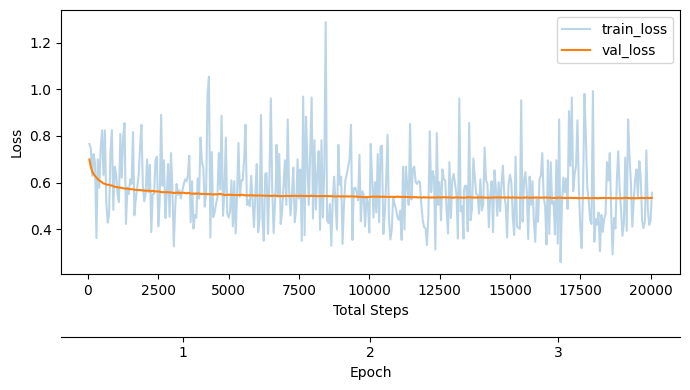

In [35]:
import csv
import matplotlib.pyplot as plt

def plot_distill_metrics(csv_path="train_distill_metrics.csv"):
    total_steps, train_losses, val_losses, epoch_bounds = [], [], [], {}

    with open(csv_path, newline="", encoding="utf-8") as f:
        for row in csv.DictReader(f):
            step = int(row["total_steps"])
            epoch = int(row["epoch"])
            total_steps.append(step)
            train_losses.append(float(row["train_loss"]))
            val_losses.append(float(row["val_loss"]))
            epoch_bounds.setdefault(epoch, [step, step])[1] = step  # first/last step for each epoch

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(total_steps, train_losses, label="train_loss", alpha=0.3)
    ax.plot(total_steps, val_losses, label="val_loss")
    ax.set_xlabel("Total Steps")
    ax.set_ylabel("Loss")
    ax.legend()

    # Epoch axis
    epoch_axis = ax.secondary_xaxis("bottom")
    epoch_axis.spines["bottom"].set_position(("outward", 45))
    epochs = sorted(epoch_bounds)
    epoch_axis.set_xticks(
        [(epoch_bounds[epoch][0] + epoch_bounds[epoch][1]) / 2 
          for epoch in epochs]
    )
    epoch_axis.set_xticklabels(epochs)
    epoch_axis.set_xlabel("Epoch")

    plt.tight_layout()
    plt.show()

plot_distill_metrics("deepseek-r1-2048_distill_metrics.csv")

- Training loss is noisy because it's based on a single sample
- We could run the evaluation on multiple samples, e.g., 25, as in the case of the validation loss, but this would increase the training time
- Validation loss is what we are interested in; we want to see it decrease
- It sharply decreases but then stops making significant progress
- We could increase the learning rate to train more aggressively, but overall, the validation curve looks good

- Similar to chapter 7, we can evaluate the resulting model checkpoints with the evaluation utilities from chapter 3

In [36]:
download_from_github(
    "ch03/02_math500-verifier-scripts/evaluate_math500.py"
)

evaluate_math500.py: 3.5 KB (cached)


PosixPath('evaluate_math500.py')

```bash
uv run evaluate_math500.py \
--dataset_size 500 \
--which_model reasoning \
--max_new_tokens 4096 \
--checkpoint_path run_11/checkpoints/distill/qwen3-0.6B-distill-step05746-epoch1.pth
```

|      | Teacher data                         | Epoch | MATH-500 Acc | Final val loss |
| ---- | ------------------------------------ | ----- | ------------ | -------------- |
| 1    | Base (chapter 3)                     | -     | 15.2%        | -              |
| 2    | Reasoning (chapter 3)                | -     | 48.2%        | -              |
| 3    | DeepSeek R1 distillation data        | 1     | 30.6%        | 0.5436         |
| 4    | DeepSeek R1 distillation data        | 2     | 32.4%        | 0.5349         |
| 5    | DeepSeek R1 distillation data        | 3     | 33.6%        | 0.5343         |
| 6    | Qwen3 235B A22B distillation data    | 1     | 45.0%        | 0.4043         |
| 7    | Qwen3 235B A22B distillation data    | 2     | 43.8%        | 0.3963         |
| 8    | Qwen3 235B A22B distillation data    | 3     | 44.2%        | 0.3948         |

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch08/CH08_F18_raschka.webp" width=500>

&nbsp;
## 8.9 Future directions for reasoning models

- No code in this section
- Also see appendix A for more references

&nbsp;
## 8.10 Conclusions

- No code in this section

- I hope you enjoyed this book!
- We are at the end, but there are more "appendix" chapters you might find useful (covering LLM architecture details, running the code in batched mode for higher throughput, discussing different evaluation methods, and more)
- Also, you can find additional bonus material in the bonus [#bonus-material](https://github.com/rasbt/reasoning-from-scratch?tab=readme-ov-file#bonus-material) section

- I regularly write about AI and LLM topics on my blog at https://magazine.sebastianraschka.com, which you may find useful

&nbsp;
## Summary

- No code in this section